<h1 align="center"><b>Gold Price Prediction Project (1970–2026 → Future Forecast)</b></h1>

## Project Overview
This project focuses on predicting gold prices using historical data from 1970 to 2026. The dataset contains daily gold prices, and machine learning models are used to analyze trends and forecast future values.

---

## Objectives
- Analyze historical gold price trends  
- Build machine learning models for prediction  
- Improve accuracy using time-series features  
- Forecast future gold prices  

---

## Import Libraries

In [220]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error

## Load Dataset

In [221]:
df=pd.read_csv(r"C:\Users\LENOVO\Desktop\MAKBIG\DATASETS\gold_price_1970_2026_daily.csv")
df

,Date,Open,High,Low,Close,Volume,USD_Index
0,1/1/1970,35.266480,35.347048,35.028732,35.184836,463815.0,101.653978
1,1/2/1970,35.118440,35.210598,35.113033,35.146764,118078.0,99.602237
2,1/3/1970,35.390481,35.401595,35.308795,35.385759,268897.0,99.372855
3,1/4/1970,35.877160,36.129634,35.819954,35.939600,441570.0,99.689258
4,1/5/1970,35.849757,35.913347,35.724345,35.866303,443895.0,99.943067
...,...,...,...,...,...,...,...
20814,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20815,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20817,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Dataset Shape

In [222]:
df.shape

(20819, 7)

In [223]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'USD_Index'], dtype='object')

## Dataset Information

In [224]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20819 entries, 0 to 20818
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       20512 non-null  object 
 1   Open       20512 non-null  float64
 2   High       20512 non-null  float64
 3   Low        20512 non-null  float64
 4   Close      20512 non-null  float64
 5   Volume     20512 non-null  float64
 6   USD_Index  20512 non-null  float64
dtypes: float64(6), object(1)
memory usage: 1.1+ MB


## Statistical Summary

In [225]:
df.describe()

,Open,High,Low,Close,Volume,USD_Index
count,20512.000000,20512.000000,20512.000000,20512.000000,20512.000000,20512.000000
mean,5576.219032,5594.105698,5558.402451,5576.050804,299144.038417,97.718837
std,10703.030233,10737.377294,10668.985440,10702.534957,115745.603693,4.492802
min,31.533304,31.597819,31.275753,31.536068,100008.000000,78.429337
25%,203.905449,204.573971,203.242883,203.872999,198585.500000,97.836168
50%,556.546539,558.043021,554.862036,556.656385,298731.500000,99.299329
75%,4239.203906,4254.166723,4225.141234,4239.503199,399180.500000,100.187778
max,48838.653380,48977.173220,48705.798960,48805.407220,499987.000000,103.847579


## Display Dataset

In [226]:
df.head(10)

,Date,Open,High,Low,Close,Volume,USD_Index
0,1/1/1970,35.266480,35.347048,35.028732,35.184836,463815.0,101.653978
1,1/2/1970,35.118440,35.210598,35.113033,35.146764,118078.0,99.602237
2,1/3/1970,35.390481,35.401595,35.308795,35.385759,268897.0,99.372855
3,1/4/1970,35.877160,36.129634,35.819954,35.939600,441570.0,99.689258
4,1/5/1970,35.849757,35.913347,35.724345,35.866303,443895.0,99.943067
5,1/6/1970,35.797587,35.983355,35.698217,35.793161,369914.0,100.017840
6,1/7/1970,36.367632,36.581380,36.331750,36.373808,367899.0,100.135445
7,1/8/1970,36.763453,36.874969,36.664207,36.665025,339524.0,101.331694
8,1/9/1970,36.480141,36.572805,36.397046,36.504246,215043.0,98.833679
9,1/10/1970,36.645413,36.751241,36.641660,36.713854,332336.0,100.870029


In [227]:
df.tail(10)

,Date,Open,High,Low,Close,Volume,USD_Index
20809,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20810,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20811,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20812,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20813,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20814,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20815,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20817,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20818,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Duplicates

In [228]:
df.duplicated().sum()

np.int64(306)

In [229]:
df.drop_duplicates(inplace=True)

## Missing Values

In [230]:
# Missing values
df.isnull().sum()

Date         1
Open         1
High         1
Low          1
Close        1
Volume       1
USD_Index    1
dtype: int64

In [231]:
df.dropna(inplace=True)

In [232]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Volume       0
USD_Index    0
dtype: int64

## Outlier Detection using Boxplot

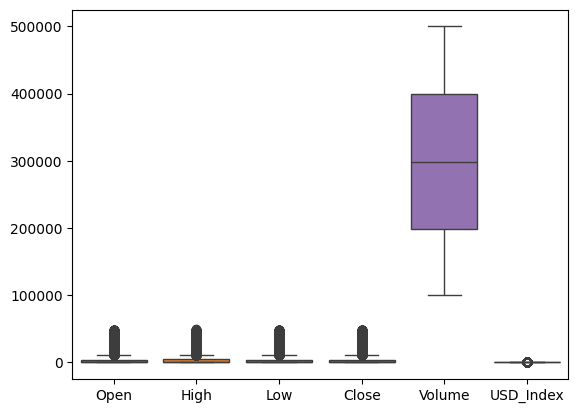

In [233]:
sns.boxplot(df)
plt.show()

## Feature Engineering

In [234]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [235]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [236]:
df.drop(['Date'], axis=1, inplace=True)

## Close Price Trend Over Years

<Axes: xlabel='Year'>

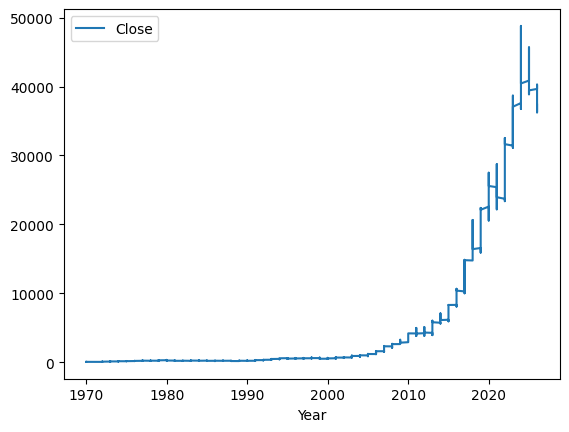

In [237]:
df.plot.line(x='Year',y='Close',use_index=True)

## Extracting 2025 Data

In [238]:
df_2025=df[df['Year']==2025]
df_2025

,Open,High,Low,Close,Volume,USD_Index,Year,Month,Day
20089,40958.22681,41015.26479,40822.28849,40872.46688,291867.0,84.905664,2025,1,1
20090,40794.94051,40990.19093,40689.00707,40907.07575,492042.0,84.142222,2025,1,2
20091,40524.87442,40677.10666,40482.96157,40596.29560,215124.0,84.187160,2025,1,3
20092,39973.46328,40128.54950,39921.76026,40076.60415,113343.0,84.439788,2025,1,4
20093,40219.95294,40511.05947,40147.40438,40437.15612,243596.0,84.079638,2025,1,5
...,...,...,...,...,...,...,...,...,...
20449,39347.71910,39546.36819,39319.13089,39403.89901,307139.0,84.086854,2025,12,27
20450,39569.30734,39614.01309,39547.23720,39593.72929,411056.0,83.175973,2025,12,28
20451,39865.68990,40011.44390,39683.27961,39709.92301,489419.0,82.930514,2025,12,29
20452,39623.84162,39771.08010,39587.99693,39695.90363,405948.0,83.539390,2025,12,30


In [239]:
df_2025_test=df_2025.Close
df_2025_test

20089    40872.46688
20090    40907.07575
20091    40596.29560
20092    40076.60415
20093    40437.15612
            ...     
20449    39403.89901
20450    39593.72929
20451    39709.92301
20452    39695.90363
20453    39445.74225
Name: Close, Length: 365, dtype: float64

In [240]:
df_2025=df_2025.drop('Close',axis=1)

In [241]:
df1 = df[df['Year'] != 2025]

In [242]:
df1

,Open,High,Low,Close,Volume,USD_Index,Year,Month,Day
0,35.266480,35.347048,35.028732,35.184836,463815.0,101.653978,1970,1,1
1,35.118440,35.210598,35.113033,35.146764,118078.0,99.602237,1970,1,2
2,35.390481,35.401595,35.308795,35.385759,268897.0,99.372855,1970,1,3
3,35.877160,36.129634,35.819954,35.939600,441570.0,99.689258,1970,1,4
4,35.849757,35.913347,35.724345,35.866303,443895.0,99.943067,1970,1,5
...,...,...,...,...,...,...,...,...,...
20507,37820.281110,37912.557000,37783.653660,37851.878550,474043.0,84.146960,2026,2,23
20508,37725.243280,37802.382180,37594.181480,37743.509630,469480.0,84.720183,2026,2,24
20509,37034.282240,37205.679120,36954.219700,37133.326400,369802.0,84.875826,2026,2,25
20510,37470.910420,37766.402500,37417.574760,37457.931930,471691.0,86.130226,2026,2,26


In [243]:
x = df1.drop('Close', axis=1)
y = df1['Close']

In [244]:
y

0           35.184836
1           35.146764
2           35.385759
3           35.939600
4           35.866303
             ...     
20507    37851.878550
20508    37743.509630
20509    37133.326400
20510    37457.931930
20511    37365.912460
Name: Close, Length: 20147, dtype: float64

## XGBoost Predicted Close Prices for 2025

In [245]:
xg=XGBRegressor(n_estimators=100,learning_rate=0.05)
model1=xg.fit(x,y)
y1_pred=model1.predict(df_2025)
y1_pred

array([40676.88 , 40658.64 , 40857.27 , 38147.855, 39544.94 , 40817.59 ,
       40798.543, 40787.94 , 40768.734, 40771.754, 40787.94 , 40785.285,
       38322.785, 40776.457, 40761.52 , 40775.5  , 40732.824, 40776.457,
       40780.676, 40795.93 , 40781.95 , 40816.137, 40594.184, 40556.22 ,
       38062.355, 38303.137, 38303.16 , 38074.23 , 38021.1  , 37998.406,
       38319.348, 38337.473, 38382.395, 38382.395, 38388.043, 40868.137,
       40695.285, 42643.09 , 42480.71 , 41883.68 , 44544.848, 44707.227,
       44548.242, 44457.98 , 44677.176, 44677.176, 44156.562, 44668.67 ,
       44757.848, 44617.586, 44583.754, 44456.906, 44456.906, 44792.465,
       44681.543, 44843.49 , 44849.33 , 44666.605, 44681.543, 44661.344,
       42480.71 , 42520.832, 42480.71 , 42043.348, 42643.09 , 42480.71 ,
       44555.254, 42480.71 , 42439.855, 42421.793, 42511.465, 42145.402,
       42478.645, 42640.71 , 42483.242, 42714.457, 42591.043, 42235.02 ,
       42601.082, 42693.34 , 42828.58 , 42869.035, 

In [246]:
print("R2:", r2_score(df_2025_test, y1_pred))
print("MAE:", mean_absolute_error(df_2025_test, y1_pred))
print("RMSE:", np.sqrt(mean_squared_error(df_2025_test, y1_pred)))

R2: 0.7423228615750733
MAE: 632.7555789828765
RMSE: 836.4007785571339


In [247]:
print("Train Score:", model1.score(x, y))
print("Test Score:", model1.score(df_2025, df_2025_test))

Train Score: 0.9998477431058161
Test Score: 0.7423228615750733


## Random Forest Predicted Close Prices for 2025

In [248]:
rf=RandomForestRegressor(n_estimators=300,max_depth=15)
model2=rf.fit(x,y)
y2_pred=model2.predict(df_2025)
y2_pred

array([40857.16437123, 40796.30766643, 40557.7007455 , 40032.50863023,
       40306.42110193, 40647.99089303, 41085.24485053, 40785.68369253,
       41460.44476393, 40782.20143637, 41063.69994497, 40510.7722151 ,
       40111.89453673, 40698.5841166 , 41058.1615232 , 40882.61898963,
       40601.61453607, 40715.0417538 , 40846.08225373, 41490.6934936 ,
       41134.7532659 , 40591.17460557, 40555.58068693, 40449.0081995 ,
       39840.53003547, 40145.9457329 , 40032.80356377, 40221.58508337,
       39910.37837533, 40064.64965327, 39671.11133417, 39254.43568247,
       39090.12587477, 39752.7422326 , 40120.40931827, 40504.98825777,
       41176.8255146 , 42723.2649688 , 42851.95717073, 43370.6619885 ,
       43858.81957467, 44338.5319419 , 45110.4796474 , 44848.56220447,
       44698.0323486 , 45051.28507217, 44722.3963606 , 45004.61679797,
       45684.4562051 , 45514.26595063, 45524.6304119 , 45527.8110339 ,
       45367.61417737, 44621.68434783, 44222.74056557, 44478.9630039 ,
      

In [249]:
print("R2:", r2_score(df_2025_test, y2_pred))
print("MAE:", mean_absolute_error(df_2025_test, y2_pred))
print("RMSE:", np.sqrt(mean_squared_error(df_2025_test, y2_pred)))

R2: 0.9976614183826618
MAE: 62.586523322021385
RMSE: 79.68062826263466


In [250]:
print("Train Score:", model2.score(x, y))
print("Test Score:", model2.score(df_2025, df_2025_test))

Train Score: 0.9999994402974305
Test Score: 0.9976614183826618


## RobustScaler for Linear Regression

In [251]:
scaler = RobustScaler()

x_train = scaler.fit_transform(x)
x_test = scaler.transform(df_2025)

## Linear Regression Predicted Close Prices for 2025

In [252]:
lr=LinearRegression()
model3=lr.fit(x,y)
y3_pred=model3.predict(df_2025)
y3_pred

array([40924.51062055, 40828.86574571, 40564.32812628, 40010.50388241,
       40305.00947395, 40656.57688798, 41103.93485489, 40768.52542437,
       41524.06154652, 40744.82549891, 41094.67044335, 40445.44212568,
       40111.47135253, 40682.00917654, 41091.7942039 , 40904.26661032,
       40728.65759635, 40721.27355437, 40870.53419835, 41415.32609012,
       41152.17716925, 40617.79128234, 40566.41788404, 40467.30503333,
       39898.15170111, 40148.38375767, 39982.8756679 , 40203.66178313,
       39886.04670324, 40040.29774438, 39555.65280312, 39259.76227351,
       39150.01926442, 39765.47859763, 40147.21573549, 40510.61407931,
       41212.57737314, 42734.01906001, 42898.5203351 , 43421.05934406,
       43853.13655257, 44340.71939018, 45095.77330249, 44909.05561091,
       44641.03701115, 45104.17656455, 44658.83601347, 45047.37519388,
       45700.27030241, 45466.51445057, 45457.08209269, 45512.78703741,
       45355.23954862, 44564.45224494, 44270.53262913, 44511.58894189,
      

In [253]:
print("R2:", r2_score(df_2025_test, y3_pred))
print("MAE:", mean_absolute_error(df_2025_test, y3_pred))
print("RMSE:", np.sqrt(mean_squared_error(df_2025_test, y3_pred)))

R2: 0.9983966685200482
MAE: 52.06153339188791
RMSE: 65.9763284760095


In [254]:
print("Train Score:", model3.score(x, y))
print("Test Score:", model3.score(df_2025, df_2025_test))

Train Score: 0.9999969934234861
Test Score: 0.9983966685200482


In [255]:
df2=df
df2

,Open,High,Low,Close,Volume,USD_Index,Year,Month,Day
0,35.266480,35.347048,35.028732,35.184836,463815.0,101.653978,1970,1,1
1,35.118440,35.210598,35.113033,35.146764,118078.0,99.602237,1970,1,2
2,35.390481,35.401595,35.308795,35.385759,268897.0,99.372855,1970,1,3
3,35.877160,36.129634,35.819954,35.939600,441570.0,99.689258,1970,1,4
4,35.849757,35.913347,35.724345,35.866303,443895.0,99.943067,1970,1,5
...,...,...,...,...,...,...,...,...,...
20507,37820.281110,37912.557000,37783.653660,37851.878550,474043.0,84.146960,2026,2,23
20508,37725.243280,37802.382180,37594.181480,37743.509630,469480.0,84.720183,2026,2,24
20509,37034.282240,37205.679120,36954.219700,37133.326400,369802.0,84.875826,2026,2,25
20510,37470.910420,37766.402500,37417.574760,37457.931930,471691.0,86.130226,2026,2,26


## Lag and Rolling Feature Engineering

In [256]:
df2['lag1'] = df2['Close'].shift(1)
df2['lag7'] = df2['Close'].shift(7)
df2['lag30'] = df2['Close'].shift(30)
df2['rolling_mean_7'] = df2['Close'].rolling(7).mean()
df2['rolling_mean_30'] = df2['Close'].rolling(30).mean()
df2['rolling_std_7'] = df2['Close'].rolling(7).std()
df2

,Open,High,Low,Close,Volume,USD_Index,Year,Month,Day,lag1,lag7,lag30,rolling_mean_7,rolling_mean_30,rolling_std_7
0,35.266480,35.347048,35.028732,35.184836,463815.0,101.653978,1970,1,1,NaN,NaN,NaN,NaN,NaN,NaN
1,35.118440,35.210598,35.113033,35.146764,118078.0,99.602237,1970,1,2,35.184836,NaN,NaN,NaN,NaN,NaN
2,35.390481,35.401595,35.308795,35.385759,268897.0,99.372855,1970,1,3,35.146764,NaN,NaN,NaN,NaN,NaN
3,35.877160,36.129634,35.819954,35.939600,441570.0,99.689258,1970,1,4,35.385759,NaN,NaN,NaN,NaN,NaN
4,35.849757,35.913347,35.724345,35.866303,443895.0,99.943067,1970,1,5,35.939600,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20507,37820.281110,37912.557000,37783.653660,37851.878550,474043.0,84.146960,2026,2,23,37186.728810,36491.50176,38216.74299,37061.855989,36924.838148,407.775743
20508,37725.243280,37802.382180,37594.181480,37743.509630,469480.0,84.720183,2026,2,24,37851.878550,36768.23601,37463.80321,37201.180791,36934.161695,454.651062
20509,37034.282240,37205.679120,36954.219700,37133.326400,369802.0,84.875826,2026,2,25,37743.509630,37105.02865,37050.22384,37205.223327,36936.931780,453.778602
20510,37470.910420,37766.402500,37417.574760,37457.931930,471691.0,86.130226,2026,2,26,37133.326400,37125.97252,36685.00699,37252.646100,36962.695945,461.397990


In [257]:
df2.dropna(inplace=True)

In [258]:
features = ['lag1','lag7','lag30','Year','Month','Day','rolling_mean_7','rolling_mean_30','rolling_std_7']

X2 = df[features]
y2 = df['Close']


## Train-Test Split

In [259]:
train = df2[df2['Year'] < 2025]
test = df2[df2['Year'] >= 2025]

X2_train = train[features]
y2_train = train['Close']

X2_test = test[features]
y2_test = test['Close']


In [260]:
df2['Date'] = pd.to_datetime(df2[['Year','Month','Day']])
df2 = df2.sort_values('Date')
df2

,Open,High,Low,Close,Volume,USD_Index,Year,Month,Day,lag1,lag7,lag30,rolling_mean_7,rolling_mean_30,rolling_std_7,Date
30,33.222333,33.300778,33.021908,33.187952,260040.0,100.889874,1970,1,31,33.378233,34.025658,35.184836,33.565706,35.013086,0.255157,1970-01-31
31,33.727843,33.819209,33.643894,33.818558,471999.0,98.985248,1970,2,1,33.187952,33.851085,35.146764,33.561059,34.968813,0.249323,1970-02-01
32,33.804496,34.183000,33.718365,33.824140,402869.0,98.111203,1970,2,2,33.818558,33.898822,35.385759,33.550390,34.916759,0.233560,1970-02-02
33,33.529942,33.824433,33.394714,33.478305,104727.0,99.502269,1970,2,3,33.824140,33.520941,35.939600,33.544299,34.834716,0.235008,1970-02-03
34,33.860388,34.001778,33.762523,33.764943,263192.0,99.934858,1970,2,4,33.478305,33.657211,35.866303,33.559690,34.764670,0.246863,1970-02-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20507,37820.281110,37912.557000,37783.653660,37851.878550,474043.0,84.146960,2026,2,23,37186.728810,36491.501760,38216.742990,37061.855989,36924.838148,407.775743,2026-02-23
20508,37725.243280,37802.382180,37594.181480,37743.509630,469480.0,84.720183,2026,2,24,37851.878550,36768.236010,37463.803210,37201.180791,36934.161695,454.651062,2026-02-24
20509,37034.282240,37205.679120,36954.219700,37133.326400,369802.0,84.875826,2026,2,25,37743.509630,37105.028650,37050.223840,37205.223327,36936.931780,453.778602,2026-02-25
20510,37470.910420,37766.402500,37417.574760,37457.931930,471691.0,86.130226,2026,2,26,37133.326400,37125.972520,36685.006990,37252.646100,36962.695945,461.397990,2026-02-26


## 365-Day Future Forecast using XGBoost

In [261]:
model4=XGBRegressor(n_estimators=300,learning_rate=0.05)
model4.fit(X2_train,y2_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [262]:
future_days = 365

last_data = df.copy()
future_predictions = []

for i in range(future_days):

    last_row = last_data.iloc[-1]

    next_date = last_row['Date'] + pd.Timedelta(days=1)

    new_row = {}

    # Lag features
    new_row['lag1'] = last_row['Close']
    new_row['lag7'] = last_data['Close'].iloc[-7]
    new_row['lag30'] = last_data['Close'].iloc[-30]

    # Rolling features
    new_row['rolling_mean_7'] = last_data['Close'].tail(7).mean()
    new_row['rolling_mean_30'] = last_data['Close'].tail(30).mean()
    new_row['rolling_std_7'] = last_data['Close'].tail(7).std()

    # Date features
    new_row['Year'] = next_date.year
    new_row['Month'] = next_date.month
    new_row['Day'] = next_date.day

    # Keep same feature order as training
    X_new = pd.DataFrame([new_row])[features]

    pred = model4.predict(X_new)[0]

    # Store prediction
    new_row['Close'] = pred
    new_row['Date'] = next_date

    future_predictions.append(new_row)

    # Append back for recursive forecasting
    last_data = pd.concat(
        [last_data, pd.DataFrame([new_row])],
        ignore_index=True
    )

In [263]:
future_df = pd.DataFrame(future_predictions)
future_df

,lag1,lag7,lag30,rolling_mean_7,rolling_mean_30,rolling_std_7,Year,Month,Day,Close,Date
0,37365.912460,36711.115930,36255.966020,37350.057673,36994.967370,387.387011,2026,2,28,37714.753906,2026-02-28
1,37714.753906,37186.728810,36631.020770,37493.434527,37043.593633,283.216794,2026,3,1,37857.886719,2026-03-01
2,37857.886719,37851.878550,37083.801870,37589.314228,37084.489165,275.583350,2026,3,2,38098.535156,2026-03-02
3,38098.535156,37743.509630,36986.439990,37624.550886,37118.313608,325.922198,2026,3,3,38281.722656,2026-03-03
4,38281.722656,37133.326400,36904.686570,37701.438461,37161.489697,411.033927,2026,3,4,38344.941406,2026-03-04
...,...,...,...,...,...,...,...,...,...,...,...
360,38428.519531,38425.132812,37845.859375,38395.997768,38105.418880,23.750957,2027,2,23,38142.972656,2027-02-23
361,38142.972656,38407.347656,38020.519531,38355.689174,38115.322656,95.902750,2027,2,24,38344.125000,2027-02-24
362,38344.125000,38374.910156,37922.894531,38346.657366,38126.109505,93.164855,2027,2,25,38073.570312,2027-02-25
363,38073.570312,38379.699219,37957.187500,38303.608817,38131.132031,137.164267,2027,2,26,38129.132812,2027-02-26


## Future Gold Price Trend (2027)

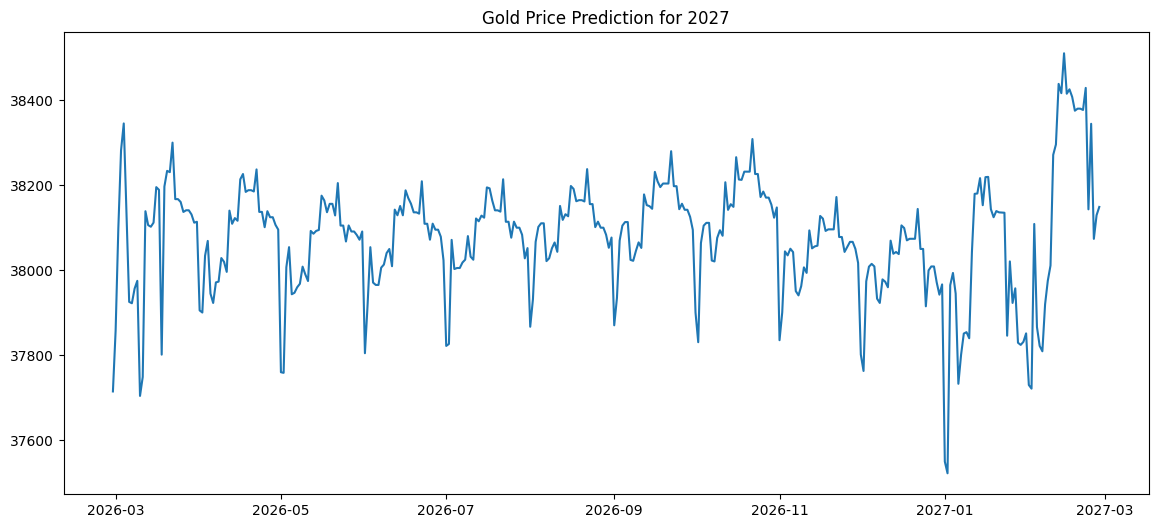

In [264]:
plt.figure(figsize=(14,6))
plt.plot(future_df['Date'],future_df['Close'])
plt.title("Gold Price Prediction for 2027")
plt.show()

# Conclusion

This project successfully analyzed historical gold price data from **1970 to 2026** and developed a machine learning model to forecast future gold prices.

Throughout the project:
- Cleaned and preprocessed the dataset by handling missing values and duplicates  
- Performed exploratory data analysis to identify historical trends  
- Applied feature engineering techniques such as **Year, Month, Day extraction**  
- Improved prediction performance using **lag features** and **rolling statistics**  
- Trained and compared multiple machine learning models including:
  - XGBoost  
  - Random Forest Regressor  
  - Linear Regression  

Among all models, **XGBoost with lag and rolling features achieved better forecasting performance** and was selected for future forecasting.

Using the trained model, the project successfully generated **gold price predictions for the next 365 days**, helping estimate future market trends based on historical patterns.

However, gold prices are influenced by external factors such as inflation, interest rates, global economic events, and geopolitical situations. Adding these real-world factors could improve future prediction accuracy.

Overall, this project demonstrates strong practical knowledge in:
- Data preprocessing  
- Feature engineering  
- Machine learning modeling  
- Time-series forecasting  
- Data visualization  

